# LLM tóm tắt


In [127]:
import time
start = time.time()

!pip install -U "transformers" "accelerate" "bitsandbytes>=0.46.1" "sentencepiece"

end = time.time()
print(f"Thời gian chạy cell 1: {end - start:.2f} giây")



Thời gian chạy cell 1: 4.11 giây


In [128]:
import time
start = time.time()

import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

end = time.time()
print(f"Thời gian chạy cell 2: {end - start:.2f} giây")



CUDA available: True
GPU: Tesla T4
Thời gian chạy cell 2: 0.00 giây


In [129]:
import time
start = time.time()

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

end = time.time()
print(f"Thời gian chạy cell 3: {end - start:.2f} giây")



Thời gian chạy cell 3: 0.00 giây


In [130]:
import time
start = time.time()

SUMMARY_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

summary_tokenizer = AutoTokenizer.from_pretrained(
    SUMMARY_MODEL_NAME,
    trust_remote_code=True
)

summary_model = AutoModelForCausalLM.from_pretrained(
    SUMMARY_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

summary_model.eval()

print("Loaded summary model:", SUMMARY_MODEL_NAME)

end = time.time()
print(f"Thời gian chạy cell 4: {end - start:.2f} giây")



Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loaded summary model: Qwen/Qwen2.5-7B-Instruct
Thời gian chạy cell 4: 172.17 giây


# Xử Lý data


In [131]:
import time
start = time.time()

youtube_url = "https://youtu.be/sAIu0VXja7k?si=D9nVqQDLHlbkNjlL"

end = time.time()
print(f"Thời gian chạy cell 6: {end - start:.2f} giây")



Thời gian chạy cell 6: 0.00 giây


In [132]:
import time
start = time.time()

!pip install -q yt-dlp youtube-transcript-api faster-whisper

end = time.time()
print(f"Thời gian chạy cell 7: {end - start:.2f} giây")



Thời gian chạy cell 7: 3.55 giây


In [133]:
import time
start = time.time()

import os
import json
from pathlib import Path

import yt_dlp
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import (
    NoTranscriptFound,
    TranscriptsDisabled,
    VideoUnavailable
)

# Tạo thư mục lưu phụ đề
BASE_DIR = Path("/kaggle/working/")
DATA_DIR = BASE_DIR / "data"
AUDIO_DIR = BASE_DIR / "audio"
SUB_DIR = DATA_DIR / "subtitles"
META_DIR = DATA_DIR / "metadata"

DATA_DIR.mkdir(parents=True, exist_ok=True)
AUDIO_DIR.mkdir(parents=True, exist_ok=True)
SUB_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

print("Đã tạo thư mục:")
print(SUB_DIR)
print(META_DIR)
print(AUDIO_DIR)

end = time.time()
print(f"Thời gian chạy cell 8: {end - start:.2f} giây")



Đã tạo thư mục:
/kaggle/working/data/subtitles
/kaggle/working/data/metadata
/kaggle/working/audio
Thời gian chạy cell 8: 0.00 giây


## Audio


In [134]:
import time
start = time.time()

def download_audio_for_whisper(youtube_url: str, video_id: str) -> Path:
    """
    Download audio từ YouTube để dùng Whisper ASR.
    Output file: /kaggle/working/video_rag_project/audio/{video_id}.mp3
    """
    output_template = str(AUDIO_DIR / f"{video_id}.%(ext)s")

    ydl_opts = {
        "format": "bestaudio/best",
        "outtmpl": output_template,
        "quiet": True,
        "noplaylist": True,
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([youtube_url])

    audio_path = AUDIO_DIR / f"{video_id}.mp3"

    if not audio_path.exists():
        raise FileNotFoundError(f"Không tìm thấy audio file: {audio_path}")

    return audio_path

end = time.time()
print(f"Thời gian chạy cell 10: {end - start:.2f} giây")



Thời gian chạy cell 10: 0.00 giây


In [135]:
import time
start = time.time()

def transcribe_with_faster_whisper(audio_path: Path, language: str = None, model_size: str = "small") -> dict:
    """
    Dùng faster-whisper để ASR nếu video không có subtitle.
    
    model_size có thể dùng:
    - tiny
    - base
    - small
    - medium
    
    Trên Kaggle nên bắt đầu với small hoặc base.
    """
    from faster_whisper import WhisperModel

    # Nếu Kaggle có GPU T4 thì dùng cuda.
    # Nếu không có GPU, đổi device="cpu", compute_type="int8".
    try:
        model = WhisperModel(model_size, device="cuda", compute_type="float16")
    except Exception:
        model = WhisperModel(model_size, device="cpu", compute_type="int8")

    segments_iter, info = model.transcribe(
        str(audio_path),
        language=language,
        vad_filter=True,
        beam_size=5
    )

    segments = []
    for seg in segments_iter:
        text = seg.text.strip()
        if not text:
            continue

        segments.append({
            "start": round(float(seg.start), 2),
            "end": round(float(seg.end), 2),
            "text": text
        })

    return {
        "segments": segments,
        "metadata": {
            "source": "whisper",
            "language": info.language,
            "confidence": getattr(info, "language_probability", None)
        }
    }

end = time.time()
print(f"Thời gian chạy cell 11: {end - start:.2f} giây")



Thời gian chạy cell 11: 0.00 giây


# metadata + sub


In [136]:
import time
start = time.time()

def get_video_id(url: str) -> str:
    ydl_opts = {
        "quiet": True,
        "skip_download": True,
        "ignoreerrors": True,
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=False)

    if not info:
        raise ValueError("Không lấy được thông tin video.")

    return info.get("id")

end = time.time()
print(f"Thời gian chạy cell 13: {end - start:.2f} giây")



Thời gian chạy cell 13: 0.00 giây


In [137]:
import time
start = time.time()

def get_youtube_metadata(url: str) -> dict:
    ydl_opts = {
        "quiet": True,
        "skip_download": True,
        "ignoreerrors": True,
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=False)

    if not info:
        raise ValueError("Không lấy được metadata video.")

    metadata = {
        "video_id": info.get("id"),
        "youtube_url": url,
        "title": info.get("title"),
        "description": info.get("description"),
        "tags": info.get("tags", []),
        "total_duration": info.get("duration"),
        "channel_name": info.get("channel"),
        "channel_id": info.get("channel_id"),
        "uploader": info.get("uploader"),
        "view_count": info.get("view_count"),
        "like_count": info.get("like_count"),
        "comment_count": info.get("comment_count"),
        "published_at": info.get("upload_date"),
        "thumbnail": info.get("thumbnail"),
        "webpage_url": info.get("webpage_url"),
    }

    # Đổi YYYYMMDD -> YYYY-MM-DD
    if metadata["published_at"] and len(metadata["published_at"]) == 8:
        d = metadata["published_at"]
        metadata["published_at"] = f"{d[:4]}-{d[4:6]}-{d[6:]}"

    return metadata

end = time.time()
print(f"Thời gian chạy cell 14: {end - start:.2f} giây")



Thời gian chạy cell 14: 0.00 giây


In [138]:
import time
start = time.time()

# tải metadata
video_id = get_video_id(youtube_url)
metadata = get_youtube_metadata(youtube_url)

metadata_path = META_DIR / f"{video_id}_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Video ID:", video_id)
print("Title:", metadata["title"])
print("Đã lưu metadata:", metadata_path)

end = time.time()
print(f"Thời gian chạy cell 15: {end - start:.2f} giây")



Video ID: sAIu0VXja7k
Title: 99% Người Dùng AI Không Biết 5 Nền Tảng Cơ Bản Này
Đã lưu metadata: /kaggle/working/data/metadata/sAIu0VXja7k_metadata.json
Thời gian chạy cell 15: 1.84 giây


In [139]:
import time
start = time.time()

def normalize_transcript(items):
    """
    Hỗ trợ cả 2 dạng dữ liệu:

    Dạng cũ:
    {
        "start": ...,
        "duration": ...,
        "text": ...
    }

    Dạng mới:
    FetchedTranscriptSnippet(
        start=...,
        duration=...,
        text=...
    )
    """

    segments = []

    for item in items:
        # Trường hợp item là dict
        if isinstance(item, dict):
            start = item.get("start", 0)
            duration = item.get("duration", 0)
            text = item.get("text", "")

        # Trường hợp item là object
        else:
            start = getattr(item, "start", 0)
            duration = getattr(item, "duration", 0)
            text = getattr(item, "text", "")

        segments.append({
            "start": round(float(start), 3),
            "duration": round(float(duration), 3),
            "end": round(float(start + duration), 3),
            "text": text.replace("\n", " ").strip()
        })

    return segments

end = time.time()
print(f"Thời gian chạy cell 16: {end - start:.2f} giây")



Thời gian chạy cell 16: 0.00 giây


In [140]:
import time
start = time.time()

def save_vi_subtitle(video_id: str, transcript_items):
    segments = normalize_transcript(transcript_items)

    data = {
        "video_id": video_id,
        "language": "vi",
        "total_segments": len(segments),
        "segments": segments
    }

    output_path = SUB_DIR / f"{video_id}_vi.json"

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

    print("Đã lưu phụ đề tiếng Việt:")
    print(output_path)

    return output_path

end = time.time()
print(f"Thời gian chạy cell 17: {end - start:.2f} giây")



Thời gian chạy cell 17: 0.00 giây


In [141]:
import time
start = time.time()

def download_vi_subtitle(video_id: str):
    api = YouTubeTranscriptApi()

    try:
        transcript_list = api.list(video_id)

        print("Danh sách phụ đề có sẵn:")
        for transcript in transcript_list:
            print(
                "-",
                transcript.language_code,
                "|",
                transcript.language,
                "| generated:",
                transcript.is_generated,
                "| translatable:",
                transcript.is_translatable
            )

        # Tìm phụ đề tiếng Việt
        vi_transcript = transcript_list.find_transcript(["vi"])

        # Tải phụ đề
        vi_items = vi_transcript.fetch()

        # Lưu JSON
        output_path = save_vi_subtitle(video_id, vi_items)

        return output_path

    except NoTranscriptFound:
        print("Không tìm thấy phụ đề tiếng Việt cho video này.")
        return None

    except TranscriptsDisabled:
        print("Video này đã tắt phụ đề.")
        return None

    except VideoUnavailable:
        print("Video không khả dụng.")
        return None

    except Exception as e:
        print("Lỗi khi tải phụ đề tiếng Việt:")
        print(e)
        return None

end = time.time()
print(f"Thời gian chạy cell 18: {end - start:.2f} giây")



Thời gian chạy cell 18: 0.00 giây


In [142]:
import time
start = time.time()

vi_subtitle_path = download_vi_subtitle(video_id)

vi_subtitle_path

end = time.time()
print(f"Thời gian chạy cell 19: {end - start:.2f} giây")



Danh sách phụ đề có sẵn:
- vi | Vietnamese (auto-generated) | generated: True | translatable: True
Đã lưu phụ đề tiếng Việt:
/kaggle/working/data/subtitles/sAIu0VXja7k_vi.json
Thời gian chạy cell 19: 0.62 giây


## Làm sạch transcript


In [143]:
import time
start = time.time()

# Hàm làm sạch text trong từng segment

import re
import html
import json
from pathlib import Path

def clean_segment_text(text: str) -> str:
    """
    Làm sạch nội dung text của 1 transcript segment.
    """
    if text is None:
        return ""

    # Decode HTML entity: &amp;, &#39;, ...
    text = html.unescape(text)

    # Xóa HTML tag nếu có
    text = re.sub(r"<[^>]+>", " ", text)

    # Xóa các tag rác thường gặp trong subtitle
    noise_patterns = [
        r"\[music\]",
        r"\[applause\]",
        r"\[laughter\]",
        r"\[sound\]",
        r"\[noise\]",
        r"\(music\)",
        r"\(applause\)",
        r"\(laughter\)",
    ]

    for pattern in noise_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)

    # Xóa ký tự xuống dòng trong segment
    text = text.replace("\n", " ")

    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text

end = time.time()
print(f"Thời gian chạy cell 21: {end - start:.2f} giây")



Thời gian chạy cell 21: 0.00 giây


In [144]:
import time
start = time.time()

# Hàm kiểm tra duplicate subtitle

def normalize_for_duplicate_check(text: str) -> str:
    """
    Chuẩn hóa text để kiểm tra trùng lặp.
    """
    text = text.lower().strip()
    text = re.sub(r"[^\w\sÀ-ỹ]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def is_duplicate_text(current_text: str, previous_text: str) -> bool:
    """
    Kiểm tra 2 đoạn text có bị trùng không.
    Ở bước này chỉ xử lý trùng đơn giản để tránh xóa nhầm.
    """
    cur = normalize_for_duplicate_check(current_text)
    prev = normalize_for_duplicate_check(previous_text)

    if not cur or not prev:
        return False

    # Trùng hoàn toàn
    if cur == prev:
        return True

    # Một câu rất ngắn bị lặp lại trong câu sau
    if len(cur.split()) <= 4 and cur in prev:
        return True

    if len(prev.split()) <= 4 and prev in cur:
        return True

    return False

end = time.time()
print(f"Thời gian chạy cell 22: {end - start:.2f} giây")



Thời gian chạy cell 22: 0.00 giây


In [145]:
import time
start = time.time()

# Hàm sửa timestamp bị lỗi nhẹ
# Segment sau bắt đầu trước khi segment trước kết thúc. Nhưng đây là chuyện bình thường của YouTube auto subtitle. Không nên sửa quá mạnh, vì có thể mất timestamp gốc.

# Cách xử lý ở đây:

# - Nếu end <= start thì sửa end = start + 0.5
# - Nếu start bị âm thì đưa về 0
# - Nếu overlap nhẹ thì vẫn giữ nguyên
# - Không ép segment sau phải bắt đầu sau segment trước

def fix_segment_time(start, end, min_duration: float = 0.3):
    """
    Sửa timestamp lỗi cơ bản.
    Không xử lý overlap mạnh ở đây để giữ timestamp gốc.
    """
    try:
        start = float(start)
        end = float(end)
    except Exception:
        start = 0.0
        end = min_duration

    if start < 0:
        start = 0.0

    if end <= start:
        end = start + min_duration

    return round(start, 2), round(end, 2)

end = time.time()
print(f"Thời gian chạy cell 23: {end - start:.2f} giây")



Thời gian chạy cell 23: 0.00 giây


In [146]:
import time
start = time.time()

if vi_subtitle_path:
    with open(vi_subtitle_path, "r", encoding="utf-8") as f:
        vi_data = json.load(f)

    print("Tổng số segment:", vi_data["total_segments"])
    vi_data["segments"][:5]
else:
    print("Chưa có file phụ đề.")

end = time.time()
print(f"Thời gian chạy cell 24: {end - start:.2f} giây")



Tổng số segment: 524
Thời gian chạy cell 24: 0.00 giây


In [147]:
import time
start = time.time()

# if vi_subtitle_path:
#     texts = []

#     for seg in vi_data["segments"]:
#         texts.append(seg["text"])

#     full_text = " ".join(texts)

#     print(full_text)
# else:
#     print("Chưa có phụ đề để in.")

end = time.time()
print(f"Thời gian chạy cell 25: {end - start:.2f} giây")



Thời gian chạy cell 25: 0.00 giây


In [148]:
import time
start = time.time()

import time

start = time.time()

print("trung")

end = time.time()

print(f"Thời gian QA: {end - start:.2f} giây")

end = time.time()
print(f"Thời gian chạy cell 26: {end - start:.2f} giây")



trung
Thời gian QA: 0.00 giây
Thời gian chạy cell 26: 0.00 giây


# vinai/phobert-base


In [149]:
import time
start = time.time()

import os
import json
import time
import math
import numpy as np
from pathlib import Path

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel

end = time.time()
print(f"Thời gian chạy cell 28: {end - start:.2f} giây")



Thời gian chạy cell 28: 0.00 giây


In [150]:
import time
start = time.time()

PHOBERT_MODEL = "vinai/phobert-base"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(PHOBERT_MODEL)
phobert = AutoModel.from_pretrained(PHOBERT_MODEL).to(device)
phobert.eval()

print("Device:", device)

end = time.time()
print(f"Thời gian chạy cell 29: {end - start:.2f} giây")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Thời gian chạy cell 29: 2.86 giây


In [151]:
import time
start = time.time()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)

    return sum_embeddings / sum_mask


@torch.no_grad()
def get_phobert_embedding(text, max_length=256):
    inputs = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = phobert(**inputs)
    embedding = mean_pooling(outputs, inputs["attention_mask"])

    embedding = F.normalize(embedding, p=2, dim=1)

    return embedding.cpu().numpy()[0]

end = time.time()
print(f"Thời gian chạy cell 30: {end - start:.2f} giây")



Thời gian chạy cell 30: 0.00 giây


In [152]:
import time
start = time.time()

def load_transcript(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict) and "segments" in data:
        print("Loaded segments:", len(data["segments"]))
        return data["segments"]

    if isinstance(data, list):
        print("Loaded list transcript:", len(data))
        return data

    raise ValueError("Không tìm thấy key 'segments' trong transcript JSON")

end = time.time()
print(f"Thời gian chạy cell 31: {end - start:.2f} giây")



Thời gian chạy cell 31: 0.00 giây


In [153]:
import time
start = time.time()

def split_transcript_to_blocks(transcript, block_size=60):
    blocks = []

    if len(transcript) == 0:
        return blocks

    current_block = None

    for item in transcript:
        start = float(item["start"])
        end = float(item.get("end", start + float(item.get("duration", 0))))
        text = item.get("text", "").strip()

        if not text:
            continue

        block_id = int(start // block_size)

        if current_block is None:
            current_block = {
                "block_id": block_id,
                "start_time": block_id * block_size,
                "end_time": (block_id + 1) * block_size,
                "texts": []
            }

        if block_id != current_block["block_id"]:
            current_block["text"] = " ".join(current_block["texts"])
            del current_block["texts"]
            blocks.append(current_block)

            current_block = {
                "block_id": block_id,
                "start_time": block_id * block_size,
                "end_time": (block_id + 1) * block_size,
                "texts": []
            }

        current_block["texts"].append(text)

    if current_block is not None and current_block["texts"]:
        current_block["text"] = " ".join(current_block["texts"])
        del current_block["texts"]
        blocks.append(current_block)

    return blocks

end = time.time()
print(f"Thời gian chạy cell 32: {end - start:.2f} giây")



Thời gian chạy cell 32: 0.00 giây


In [154]:
import time
start = time.time()

def embed_blocks_with_phobert(blocks):
    for block in blocks:
        text = block["text"]
        emb = get_phobert_embedding(text)

        block["embedding_model"] = "vinai/phobert-base"
        block["embedding"] = emb.tolist()

    return blocks

end = time.time()
print(f"Thời gian chạy cell 33: {end - start:.2f} giây")



Thời gian chạy cell 33: 0.00 giây


In [155]:
import time
start = time.time()

def cosine_similarity(vec_a, vec_b):
    a = np.array(vec_a)
    b = np.array(vec_b)

    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


def compute_adjacent_similarity(blocks):
    for i in range(len(blocks) - 1):
        sim = cosine_similarity(
            blocks[i]["embedding"],
            blocks[i + 1]["embedding"]
        )

        blocks[i]["next_similarity"] = sim

    if blocks:
        blocks[-1]["next_similarity"] = None

    return blocks

end = time.time()
print(f"Thời gian chạy cell 34: {end - start:.2f} giây")



Thời gian chạy cell 34: 0.00 giây


In [156]:
import time
start = time.time()

def detect_topic_shift(blocks, threshold=0.60):
    for i in range(len(blocks) - 1):
        sim = blocks[i]["next_similarity"]

        if sim is not None and sim < threshold:
            blocks[i]["topic_shift_after"] = True
        else:
            blocks[i]["topic_shift_after"] = False

    if blocks:
        blocks[-1]["topic_shift_after"] = True

    return blocks

end = time.time()
print(f"Thời gian chạy cell 35: {end - start:.2f} giây")



Thời gian chạy cell 35: 0.00 giây


In [157]:
import time
start = time.time()

def merge_blocks_to_topics(blocks):
    topics = []

    current_topic = {
        "topic_id": 0,
        "start_time": None,
        "end_time": None,
        "block_ids": [],
        "texts": []
    }

    topic_id = 0

    for block in blocks:
        if current_topic["start_time"] is None:
            current_topic["start_time"] = block["start_time"]

        current_topic["end_time"] = block["end_time"]
        current_topic["block_ids"].append(block["block_id"])
        current_topic["texts"].append(block["text"])

        if block.get("topic_shift_after", False):
            current_topic["text"] = " ".join(current_topic["texts"])
            del current_topic["texts"]

            topics.append(current_topic)

            topic_id += 1
            current_topic = {
                "topic_id": topic_id,
                "start_time": None,
                "end_time": None,
                "block_ids": [],
                "texts": []
            }

    return topics

end = time.time()
print(f"Thời gian chạy cell 36: {end - start:.2f} giây")



Thời gian chạy cell 36: 0.00 giây


In [158]:
import time
start = time.time()

start = time.time()
json_path = SUB_DIR / f"{video_id}_vi.json"

transcript = load_transcript(json_path)

blocks = split_transcript_to_blocks(transcript, block_size=60)
print("Total blocks:", len(blocks))

blocks = embed_blocks_with_phobert(blocks)
blocks = compute_adjacent_similarity(blocks)
blocks = detect_topic_shift(blocks, threshold=0.90)

topics = merge_blocks_to_topics(blocks)
print("Total topics:", len(topics))

end = time.time()
print(f"Thời gian QA: {end - start:.2f} giây")

end = time.time()
print(f"Thời gian chạy cell 37: {end - start:.2f} giây")



Loaded segments: 524
Total blocks: 17
Total topics: 3
Thời gian QA: 0.38 giây
Thời gian chạy cell 37: 0.38 giây


In [159]:
import time
start = time.time()

def sec_to_time(sec):
    sec = int(sec)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60

    if h > 0:
        return f"{h:02d}:{m:02d}:{s:02d}"
    return f"{m:02d}:{s:02d}"

end = time.time()
print(f"Thời gian chạy cell 38: {end - start:.2f} giây")



Thời gian chạy cell 38: 0.00 giây


In [160]:
import time
start = time.time()

def print_topics_overview(topics, max_chars=500):
    print("Total topics:", len(topics))
    print("=" * 100)

    for topic in topics:
        topic_id = topic["topic_id"]
        start = sec_to_time(topic["start_time"])
        end = sec_to_time(topic["end_time"])
        block_ids = topic["block_ids"]
        text = topic["text"]

        print(f"TOPIC {topic_id}")
        print(f"Time: {start} - {end}")
        print(f"Blocks: {block_ids}")
        print(f"Text length: {len(text)} chars")
        print("-" * 100)
        print(text[:max_chars])

        if len(text) > max_chars:
            print("...")

        print("=" * 100)

end = time.time()
print(f"Thời gian chạy cell 39: {end - start:.2f} giây")



Thời gian chạy cell 39: 0.00 giây


In [161]:
import time
start = time.time()

print_topics_overview(topics, max_chars=1000)

end = time.time()
print(f"Thời gian chạy cell 40: {end - start:.2f} giây")



Total topics: 3
TOPIC 0
Time: 00:00 - 06:00
Blocks: [0, 1, 2, 3, 4, 5]
Text length: 7750 chars
----------------------------------------------------------------------------------------------------
Nếu bạn đang học sử dụng AI mà không hiểu năm điều cơ bản sau đây thì bạn đang lãng phí thời gian và không thu lại được gì. Mình đã gặp nhiều người cố gắng học AI bằng cách học hàng loạt các công cụ khác nhau, chạy theo từng bản cập nhật vì họ sợ bị bỏ lại phía sau. Không có AI nào là tốt nhất, chỉ có AI phù hợp với tưng việc. Và đó là nền tảng đầu tiên bạn cần hiểu trước khi sử dụng bất kỳ một công cụ nào. AI bây giờ không chỉ là chat GPT, giai đoạn này đã qua từ lâu rồi. Năm nay là năm 2026 và có hàng trăm những cái công cụ, những cái mô hình và ứng dụng framework khác nhau liên tục được ra mất. Bạn sẽ không có đủ thời gian để nghiên cứu và thử nghiệm. tất cả những sản phẩm, tất cả những công cụ ngoài kia mà bạn nhìn thấy và cũng rất khó để biết công cụ nào thực sự có giá trị với mình. Những

In [162]:
import time
start = time.time()

os.makedirs("outputs", exist_ok=True)

with open("outputs/blocks_phobert.json", "w", encoding="utf-8") as f:
    json.dump(blocks, f, ensure_ascii=False, indent=2)

with open("outputs/topics_phobert.json", "w", encoding="utf-8") as f:
    json.dump(topics, f, ensure_ascii=False, indent=2)

print("Saved:")
print("outputs/blocks_phobert.json")
print("outputs/topics_phobert.json")

end = time.time()
print(f"Thời gian chạy cell 41: {end - start:.2f} giây")



Saved:
outputs/blocks_phobert.json
outputs/topics_phobert.json
Thời gian chạy cell 41: 0.02 giây


# BGE-M3


In [163]:
import time
start = time.time()

!pip install -q sentence-transformers

end = time.time()
print(f"Thời gian chạy cell 43: {end - start:.2f} giây")



Thời gian chạy cell 43: 3.55 giây


In [164]:
import time
start = time.time()

from sentence_transformers import SentenceTransformer

BGE_M3_MODEL = "BAAI/bge-m3"

bge_m3 = SentenceTransformer(BGE_M3_MODEL, device=device)
print("Loaded BGE-M3 model:", BGE_M3_MODEL)
print("Device:", device)

end = time.time()
print(f"Thời gian chạy cell 44: {end - start:.2f} giây")



Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loaded BGE-M3 model: BAAI/bge-m3
Device: cuda
Thời gian chạy cell 44: 15.38 giây


In [165]:
import time
start = time.time()

def get_bge_m3_embedding(text, batch_size=8):
    emb = bge_m3.encode(
        text,
        batch_size=batch_size,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False
    )
    return emb.astype(np.float32)


def embed_blocks_with_bge_m3(blocks, batch_size=8):
    texts = [block["text"] for block in blocks]
    embeddings = get_bge_m3_embedding(texts, batch_size=batch_size)

    for block, emb in zip(blocks, embeddings):
        block["embedding_model"] = BGE_M3_MODEL
        block["embedding"] = emb.tolist()

    return blocks

end = time.time()
print(f"Thời gian chạy cell 45: {end - start:.2f} giây")



Thời gian chạy cell 45: 0.00 giây


In [166]:
import time
start = time.time()

bge_blocks = split_transcript_to_blocks(transcript, block_size=60)
print("Total BGE-M3 blocks:", len(bge_blocks))

bge_blocks = embed_blocks_with_bge_m3(bge_blocks, batch_size=8)
bge_blocks = compute_adjacent_similarity(bge_blocks)
bge_blocks = detect_topic_shift(bge_blocks, threshold=0.70)

bge_topics = merge_blocks_to_topics(bge_blocks)
print("Total BGE-M3 topics:", len(bge_topics))

print_topics_overview(bge_topics, max_chars=1000)

end = time.time()
print(f"Thời gian chạy cell 46: {end - start:.2f} giây")



Total BGE-M3 blocks: 17
Total BGE-M3 topics: 9
Total topics: 9
TOPIC 0
Time: 00:00 - 01:00
Blocks: [0]
Text length: 1375 chars
----------------------------------------------------------------------------------------------------
Nếu bạn đang học sử dụng AI mà không hiểu năm điều cơ bản sau đây thì bạn đang lãng phí thời gian và không thu lại được gì. Mình đã gặp nhiều người cố gắng học AI bằng cách học hàng loạt các công cụ khác nhau, chạy theo từng bản cập nhật vì họ sợ bị bỏ lại phía sau. Không có AI nào là tốt nhất, chỉ có AI phù hợp với tưng việc. Và đó là nền tảng đầu tiên bạn cần hiểu trước khi sử dụng bất kỳ một công cụ nào. AI bây giờ không chỉ là chat GPT, giai đoạn này đã qua từ lâu rồi. Năm nay là năm 2026 và có hàng trăm những cái công cụ, những cái mô hình và ứng dụng framework khác nhau liên tục được ra mất. Bạn sẽ không có đủ thời gian để nghiên cứu và thử nghiệm. tất cả những sản phẩm, tất cả những công cụ ngoài kia mà bạn nhìn thấy và cũng rất khó để biết công cụ nào th

In [167]:
import time
start = time.time()

os.makedirs("outputs", exist_ok=True)

with open("outputs/blocks_bge_m3.json", "w", encoding="utf-8") as f:
    json.dump(bge_blocks, f, ensure_ascii=False, indent=2)

with open("outputs/topics_bge_m3.json", "w", encoding="utf-8") as f:
    json.dump(bge_topics, f, ensure_ascii=False, indent=2)

print("Saved:")
print("outputs/blocks_bge_m3.json")
print("outputs/topics_bge_m3.json")

end = time.time()
print(f"Thời gian chạy cell 47: {end - start:.2f} giây")



Saved:
outputs/blocks_bge_m3.json
outputs/topics_bge_m3.json
Thời gian chạy cell 47: 0.03 giây


# RoBERTa Student


In [168]:
import time
start = time.time()

from pathlib import Path
from transformers import AutoTokenizer, AutoModel

# RoBERTa Student uploaded as a Kaggle Model.
# The exact path from your screenshot is the first candidate below.
ROBERTA_STUDENT_CANDIDATE_PATHS = [
    Path("/kaggle/input/models/tuvo6804/roberta-1/pytorch/default/1"),
    Path("/kaggle/input/roberta-1/pytorch/default/1"),
    Path("/kaggle/input/roberta_1/pytorch/default/1"),
    Path("/kaggle/input/roberta-student-upload"),
    Path("roberta_student_upload"),
    Path("results_distill_phobert/model_weights"),
]

ROBERTA_STUDENT_MODEL = None
for candidate_path in ROBERTA_STUDENT_CANDIDATE_PATHS:
    if (candidate_path / "config.json").exists() and (candidate_path / "model.safetensors").exists():
        ROBERTA_STUDENT_MODEL = str(candidate_path)
        break

if ROBERTA_STUDENT_MODEL is None and Path("results.zip").exists():
    import zipfile
    with zipfile.ZipFile("results.zip", "r") as zf:
        zf.extractall(".")

    fallback_path = Path("results_distill_phobert/model_weights")
    if (fallback_path / "config.json").exists() and (fallback_path / "model.safetensors").exists():
        ROBERTA_STUDENT_MODEL = str(fallback_path)

if ROBERTA_STUDENT_MODEL is None:
    raise FileNotFoundError(
        "RoBERTa Student model not found. Check the Kaggle Input path or upload a flat model zip containing config.json, model.safetensors, vocab.txt, and bpe.codes."
    )

ROBERTA_STUDENT_INFO_PATH = Path("results_distill_phobert/model_info.json")
roberta_student_max_length = 256
if ROBERTA_STUDENT_INFO_PATH.exists():
    with open(ROBERTA_STUDENT_INFO_PATH, "r", encoding="utf-8") as f:
        roberta_student_info = json.load(f)
    roberta_student_max_length = roberta_student_info.get("max_length", roberta_student_max_length)
    print("RoBERTa Student info:", roberta_student_info)

roberta_student_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_STUDENT_MODEL)
roberta_student = AutoModel.from_pretrained(ROBERTA_STUDENT_MODEL).to(device)
roberta_student.eval()

print("Loaded local/Kaggle RoBERTa Student model:", ROBERTA_STUDENT_MODEL)
print("Device:", device)

end = time.time()
print(f"Thời gian chạy cell 49: {end - start:.2f} giây")



Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: /kaggle/input/models/tuvo6804/roberta-1/pytorch/default/1
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded local/Kaggle RoBERTa Student model: /kaggle/input/models/tuvo6804/roberta-1/pytorch/default/1
Device: cuda
Thời gian chạy cell 49: 0.36 giây


In [169]:
import time
start = time.time()

@torch.no_grad()
def get_roberta_student_embedding(text, max_length=None, batch_size=8):
    if max_length is None:
        max_length = roberta_student_max_length

    if isinstance(text, str):
        texts = [text]
        single_input = True
    else:
        texts = list(text)
        single_input = False

    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        inputs = roberta_student_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = roberta_student(**inputs)
        embeddings = mean_pooling(outputs, inputs["attention_mask"])
        embeddings = F.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings.cpu().numpy().astype(np.float32))

    embeddings = np.vstack(all_embeddings)
    return embeddings[0] if single_input else embeddings


def embed_blocks_with_roberta_student(blocks, batch_size=8):
    texts = [block["text"] for block in blocks]
    embeddings = get_roberta_student_embedding(texts, batch_size=batch_size)

    for block, emb in zip(blocks, embeddings):
        block["embedding_model"] = "local_roberta_student_distill_phobert"
        block["embedding_model_path"] = ROBERTA_STUDENT_MODEL
        block["embedding"] = emb.tolist()

    return blocks

end = time.time()
print(f"Thời gian chạy cell 50: {end - start:.2f} giây")



Thời gian chạy cell 50: 0.00 giây


In [170]:
import time
start = time.time()

roberta_student_blocks = split_transcript_to_blocks(transcript, block_size=60)
print("Total RoBERTa Student blocks:", len(roberta_student_blocks))

roberta_student_blocks = embed_blocks_with_roberta_student(roberta_student_blocks, batch_size=8)
roberta_student_blocks = compute_adjacent_similarity(roberta_student_blocks)
roberta_student_blocks = detect_topic_shift(roberta_student_blocks, threshold=0.95)

roberta_student_topics = merge_blocks_to_topics(roberta_student_blocks)
print("Total RoBERTa Student topics:", len(roberta_student_topics))

print_topics_overview(roberta_student_topics, max_chars=1000)

end = time.time()
print(f"Thời gian chạy cell 51: {end - start:.2f} giây")



Total RoBERTa Student blocks: 17
Total RoBERTa Student topics: 2
Total topics: 2
TOPIC 0
Time: 00:00 - 06:00
Blocks: [0, 1, 2, 3, 4, 5]
Text length: 7750 chars
----------------------------------------------------------------------------------------------------
Nếu bạn đang học sử dụng AI mà không hiểu năm điều cơ bản sau đây thì bạn đang lãng phí thời gian và không thu lại được gì. Mình đã gặp nhiều người cố gắng học AI bằng cách học hàng loạt các công cụ khác nhau, chạy theo từng bản cập nhật vì họ sợ bị bỏ lại phía sau. Không có AI nào là tốt nhất, chỉ có AI phù hợp với tưng việc. Và đó là nền tảng đầu tiên bạn cần hiểu trước khi sử dụng bất kỳ một công cụ nào. AI bây giờ không chỉ là chat GPT, giai đoạn này đã qua từ lâu rồi. Năm nay là năm 2026 và có hàng trăm những cái công cụ, những cái mô hình và ứng dụng framework khác nhau liên tục được ra mất. Bạn sẽ không có đủ thời gian để nghiên cứu và thử nghiệm. tất cả những sản phẩm, tất cả những công cụ ngoài kia mà bạn nhìn thấy và cũ

In [171]:
import time
start = time.time()

os.makedirs("outputs", exist_ok=True)

with open("outputs/blocks_roberta_student.json", "w", encoding="utf-8") as f:
    json.dump(roberta_student_blocks, f, ensure_ascii=False, indent=2)

with open("outputs/topics_roberta_student.json", "w", encoding="utf-8") as f:
    json.dump(roberta_student_topics, f, ensure_ascii=False, indent=2)

print("Saved:")
print("outputs/blocks_roberta_student.json")
print("outputs/topics_roberta_student.json")

end = time.time()
print(f"Thời gian chạy cell 52: {end - start:.2f} giây")



Saved:
outputs/blocks_roberta_student.json
outputs/topics_roberta_student.json
Thời gian chạy cell 52: 0.02 giây


# Summary


In [172]:
import time
start = time.time()

def qwen_generate(model, tokenizer, system_prompt, user_prompt, max_new_tokens=700):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=12000
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.3,
            top_p=0.85,
            repetition_penalty=1.05
        )

    generated_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return response.strip()

end = time.time()
print(f"Thời gian chạy cell 54: {end - start:.2f} giây")



Thời gian chạy cell 54: 0.00 giây


In [173]:
import time
start = time.time()

def format_time(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h > 0:
        return f"{h:02d}:{m:02d}:{s:02d}"
    return f"{m:02d}:{s:02d}"

end = time.time()
print(f"Thời gian chạy cell 55: {end - start:.2f} giây")



Thời gian chạy cell 55: 0.00 giây


In [174]:
import time
start = time.time()

def summarize_single_topic(topic):
    start = format_time(topic["start_time"])
    end = format_time(topic["end_time"])
    text = topic["text"]

    system_prompt = """
Ban la tro ly AI chuyen tom tat video bai giang IT/AI bang tieng Viet.
Nhiem vu cua ban la doc transcript cua mot topic va tao tieu de + bullet points ngan gon, chinh xac.
Khong bia noi dung ngoai transcript.
Tra loi bang tieng Viet.
"""

    user_prompt = f"""
Day la transcript cua mot topic trong video.

Timestamp: {start} - {end}

Transcript:
{text}

Hay tao ket qua theo dung format sau:

TITLE: <tieu de ngan gon cho topic>

BULLET_POINTS:
- <y chinh 1>
- <y chinh 2>
- <y chinh 3>
- <y chinh 4 neu co>
"""

    return qwen_generate(
        summary_model,
        summary_tokenizer,
        system_prompt,
        user_prompt,
        max_new_tokens=500
    )

end = time.time()
print(f"Thời gian chạy cell 56: {end - start:.2f} giây")



Thời gian chạy cell 56: 0.00 giây


In [175]:
import time
start = time.time()

def summarize_topics(topic_list, output_path):
    for idx, topic in enumerate(topic_list):
        print(f"Summarizing topic {idx + 1}/{len(topic_list)}...")
        topic["summary_raw"] = summarize_single_topic(topic)
        topic["timestamp"] = f'{format_time(topic["start_time"])} - {format_time(topic["end_time"])}'

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(topic_list, f, ensure_ascii=False, indent=2)

    print("Saved:", output_path)
    return topic_list

end = time.time()
print(f"Thời gian chạy cell 57: {end - start:.2f} giây")



Thời gian chạy cell 57: 0.00 giây


In [176]:
import time
start = time.time()

def build_topic_summary_context(topic_list):
    parts = []
    for topic in topic_list:
        parts.append(f"""
Topic {topic["topic_id"]}
Timestamp: {topic.get("timestamp", "")}
{topic.get("summary_raw", "")}
""")
    return "\n".join(parts)


def generate_final_summary(topic_list):
    topic_context = build_topic_summary_context(topic_list)

    system_prompt = """
Ban la tro ly AI chuyen tom tat video bai giang IT/AI bang tieng Viet.
Ban can tong hop cac topic summaries thanh mot ban tom tat cuoi cung ro rang, co cau truc.
Khong bia them noi dung khong co trong du lieu.
"""

    user_prompt = f"""
Duoi day la danh sach topic summaries cua mot video:

{topic_context}

Hay tao final summary theo dung format sau:

FINAL SUMMARY

1. Tom tat ngan 5-6 cau:
<viet doan tom tat ngan>

2. Cac noi dung chinh:
- <noi dung chinh 1>
- <noi dung chinh 2>
- <noi dung chinh 3>
- <noi dung chinh 4>
- <noi dung chinh 5 neu co>

3. Dien tien noi dung theo timestamp:
- <timestamp>: <noi dung>
- <timestamp>: <noi dung>
- <timestamp>: <noi dung>

4. Ket luan:
<ket luan ngan ve noi dung video>
"""

    return qwen_generate(
        summary_model,
        summary_tokenizer,
        system_prompt,
        user_prompt,
        max_new_tokens=1200
    )

end = time.time()
print(f"Thời gian chạy cell 58: {end - start:.2f} giây")



Thời gian chạy cell 58: 0.00 giây


In [177]:
import time
start = time.time()

def run_summary_pipeline(model_label, topic_list, topic_summary_path, final_summary_path):
    print("=" * 100)
    print(f"Summary {model_label}")
    print("=" * 100)

    topic_list = summarize_topics(topic_list, topic_summary_path)

    for topic in topic_list:
        print("=" * 100)
        print("Topic ID:", topic["topic_id"])
        print("Timestamp:", topic["timestamp"])
        print(topic["summary_raw"])

    final_summary = generate_final_summary(topic_list)
    with open(final_summary_path, "w", encoding="utf-8") as f:
        f.write(final_summary)

    print("=" * 100)
    print(f"FINAL SUMMARY {model_label}")
    print("=" * 100)
    print(final_summary)
    print("\nSaved:", final_summary_path)

    return topic_list, final_summary

end = time.time()
print(f"Thời gian chạy cell 59: {end - start:.2f} giây")



Thời gian chạy cell 59: 0.00 giây


# Summary vinai/phobert-base


In [178]:
import time
start = time.time()

topics, final_summary_phobert = run_summary_pipeline(
    model_label="vinai/phobert-base",
    topic_list=topics,
    topic_summary_path="outputs/topics_phobert_qwen25_summary.json",
    final_summary_path="outputs/final_summary_phobert_qwen25.txt"
)

end = time.time()
print(f"Thời gian chạy cell 61: {end - start:.2f} giây")



Summary vinai/phobert-base
Summarizing topic 1/3...
Summarizing topic 2/3...
Summarizing topic 3/3...
Saved: outputs/topics_phobert_qwen25_summary.json
Topic ID: 0
Timestamp: 00:00 - 06:00
TITLE: Cách Sử Dụng AI Hiệu Quả

BULLET_POINTS:
- AI không phải là công cụ duy nhất, chỉ có công cụ phù hợp với nhu cầu cụ thể
- Hiểu rõ năm điều cơ bản về AI trước khi sử dụng bất kỳ công cụ nào
- Học cách viết prompt (prom) hiệu quả để tối ưu hóa sức mạnh của AI
- AI giúp tìm kiếm thông tin nhanh chóng bằng cách cung cấp thông tin đầy đủ và ngữ cảnh
- Sử dụng AI để giải quyết vấn đề và tư vấn chiến lược, không tin hoàn toàn vào kết quả của AI
- Xây dựng một nhân viên AI thực sự bằng cách sử dụngKnowledge App và ODU AI Agent
- Kết nối AI với dữ liệu có cấu trúc trong doanh nghiệp để tạo ra AI chuyên biệt
Topic ID: 1
Timestamp: 06:00 - 16:00
TITLE: Cách Sử Dụng AI Trong Công Việc

BULLET_POINTS:
- Định rõ nhiệm vụ cho AI
- Viết theo kiểu đóng vai (ví dụ: CEO, giáo viên)
- Chỉ rõ định dạng mong muốn (

# Summary BGE-M3


In [179]:
import time
start = time.time()

bge_topics, final_summary_bge_m3 = run_summary_pipeline(
    model_label="BGE-M3",
    topic_list=bge_topics,
    topic_summary_path="outputs/topics_bge_m3_qwen25_summary.json",
    final_summary_path="outputs/final_summary_bge_m3_qwen25.txt"
)

end = time.time()
print(f"Thời gian chạy cell 63: {end - start:.2f} giây")



Summary BGE-M3
Summarizing topic 1/9...
Summarizing topic 2/9...
Summarizing topic 3/9...
Summarizing topic 4/9...
Summarizing topic 5/9...
Summarizing topic 6/9...
Summarizing topic 7/9...
Summarizing topic 8/9...
Summarizing topic 9/9...
Saved: outputs/topics_bge_m3_qwen25_summary.json
Topic ID: 0
Timestamp: 00:00 - 01:00
TITLE: 5 Điều Cơ Bản Về AI Bạn Cần Hiểu

BULLET_POINTS:
- AI không phải chỉ là chat GPT
- Không có AI nào là tốt nhất, chỉ có AI phù hợp với từng công việc
- Có hàng trăm công cụ, mô hình và framework khác nhau liên tục ra đời
- Không có đủ thời gian để nghiên cứu và thử nghiệm tất cả công cụ
- Người sử dụng AI hiệu quả không chạy theo công cụ mới liên tục
Topic ID: 1
Timestamp: 01:00 - 03:00
TITLE: Cách Sử Dụng AI Trong Tìm Kiếm Thông Tin Hiệu Quả

BULLET_POINTS:
- AI không phải là công thức dập khuôn để chat
- Hiểu rõ thông tin và ngữ cảnh để AI đưa ra tư vấn chính xác
- Sử dụng AI để giải quyết vấn đề và tư vấn chiến lược
- Không tin hoàn toàn vào AI, mà sử dụng 

# Summary RoBERTa Student


In [180]:
import time
start = time.time()

roberta_student_topics, final_summary_roberta_student = run_summary_pipeline(
    model_label="RoBERTa Student",
    topic_list=roberta_student_topics,
    topic_summary_path="outputs/topics_roberta_student_qwen25_summary.json",
    final_summary_path="outputs/final_summary_roberta_student_qwen25.txt"
)

end = time.time()
print(f"Thời gian chạy cell 65: {end - start:.2f} giây")



Summary RoBERTa Student
Summarizing topic 1/2...
Summarizing topic 2/2...
Saved: outputs/topics_roberta_student_qwen25_summary.json
Topic ID: 0
Timestamp: 00:00 - 06:00
TITLE: Cách Sử Dụng AI Hiệu Quả

BULLET_POINTS:
- AI không phải công cụ duy nhất, chỉ có công cụ phù hợp với nhu cầu cụ thể
- Hiểu rõ năm điều cơ bản về AI trước khi sử dụng công cụ
- Học cách viết prompt (prom) để tối ưu hóa sức mạnh của AI
- AI không phải là nguồn thông tin cuối cùng, cần đánh giá và phản biện kết quả
- Xây dựng nhân viên AI (employee AI) bằngKnowledge App và ODU AI Agent
- Kết nối AI với dữ liệu nội bộ để tạo ra AI thực sự hữu ích
Topic ID: 1
Timestamp: 06:00 - 17:00
TITLE: Cách Sử Dụng AI Hiệu Quả Trong Công Việc

BULLET_POINTS:
- Định rõ task và mục tiêu
- Viết theo kiểu đóng vai (roleplay)
- Chỉ rõ định dạng mong muốn trả về
- Nêu rõ ngữ cảnh và đối tượng
- Đưa ra các ví dụ tham chiếu
- Đánh giá và cải tiến kết quả
- Sử dụng các công cụ AI khác nhau phù hợp với nhu cầu
- Chọn công cụ suy luận tổng

# QA 3 model


In [181]:
import time
start = time.time()

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

QA_MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

qa_tokenizer = AutoTokenizer.from_pretrained(
    QA_MODEL_NAME,
    trust_remote_code=True
)

qa_model = AutoModelForCausalLM.from_pretrained(
    QA_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

qa_model.eval()

print("Loaded QA model 4-bit:", QA_MODEL_NAME)

end = time.time()
print(f"Thời gian chạy cell 67: {end - start:.2f} giây")



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded QA model 4-bit: Qwen/Qwen3-4B-Instruct-2507
Thời gian chạy cell 67: 101.87 giây


In [182]:
import time
start = time.time()

def cosine_similarity_np(vec_a, vec_b):
    a = np.array(vec_a, dtype=np.float32)
    b = np.array(vec_b, dtype=np.float32)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


def search_relevant_blocks_phobert(question, blocks, top_k=5):
    question_emb = get_phobert_embedding(question)
    results = []

    for block in blocks:
        score = cosine_similarity_np(question_emb, block["embedding"])
        results.append({
            "block_id": block["block_id"],
            "start_time": block["start_time"],
            "end_time": block["end_time"],
            "text": block["text"],
            "score": score
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]


def search_relevant_blocks_bge_m3(question, bge_blocks, top_k=5):
    question_emb = get_bge_m3_embedding(question)
    results = []

    for block in bge_blocks:
        score = cosine_similarity_np(question_emb, block["embedding"])
        results.append({
            "block_id": block["block_id"],
            "start_time": block["start_time"],
            "end_time": block["end_time"],
            "text": block["text"],
            "score": score
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]


def search_relevant_blocks_roberta_student(question, roberta_student_blocks, top_k=5):
    question_emb = get_roberta_student_embedding(question)
    results = []

    for block in roberta_student_blocks:
        score = cosine_similarity_np(question_emb, block["embedding"])
        results.append({
            "block_id": block["block_id"],
            "start_time": block["start_time"],
            "end_time": block["end_time"],
            "text": block["text"],
            "score": score
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

end = time.time()
print(f"Thời gian chạy cell 68: {end - start:.2f} giây")



Thời gian chạy cell 68: 0.00 giây


In [183]:
import time
start = time.time()

def qwen3_generate(system_prompt, user_prompt, max_new_tokens=800):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text = qa_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = qa_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=12000
    ).to(qa_model.device)

    with torch.no_grad():
        outputs = qa_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.2,
            top_p=0.8,
            repetition_penalty=1.05
        )

    generated_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    response = qa_tokenizer.decode(generated_ids, skip_special_tokens=True)
    return response.strip()

end = time.time()
print(f"Thời gian chạy cell 69: {end - start:.2f} giây")



Thời gian chạy cell 69: 0.00 giây


In [184]:
import time
start = time.time()

def build_rag_context(retrieved_blocks):
    context_parts = []

    for item in retrieved_blocks:
        start = format_time(item["start_time"])
        end = format_time(item["end_time"])
        score = item["score"]
        text = item["text"]

        context_parts.append(f"""
[Block {item["block_id"]}]
Timestamp: {start} - {end}
Similarity score: {score:.4f}
Content:
{text}
""")

    return "\n".join(context_parts)

end = time.time()
print(f"Thời gian chạy cell 70: {end - start:.2f} giây")



Thời gian chạy cell 70: 0.00 giây


In [185]:
import time
start = time.time()

def format_duration(seconds):
    if seconds is None:
        return "Khong ro"

    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h > 0:
        return f"{h} gio {m} phut {s} giay"
    return f"{m} phut {s} giay"


def build_metadata_context(metadata):
    title = metadata.get("title") or metadata.get("video_title") or "Khong ro"
    channel = metadata.get("channel_name") or metadata.get("channel") or metadata.get("uploader") or "Khong ro"
    url = metadata.get("webpage_url") or metadata.get("youtube_url") or metadata.get("url") or "Khong ro"
    duration = format_duration(metadata.get("total_duration") or metadata.get("duration"))
    upload_date = metadata.get("published_at") or metadata.get("upload_date") or "Khong ro"
    view_count = metadata.get("view_count", "Khong ro")
    like_count = metadata.get("like_count", "Khong ro")
    description = metadata.get("description", "")

    if description and len(description) > 1500:
        description = description[:1500] + "..."

    return f"""
VIDEO METADATA:
Title: {title}
Channel: {channel}
URL: {url}
Duration: {duration}
Upload date: {upload_date}
View count: {view_count}
Like count: {like_count}

Description:
{description}
"""

end = time.time()
print(f"Thời gian chạy cell 71: {end - start:.2f} giây")



Thời gian chạy cell 71: 0.00 giây


In [186]:
import time
start = time.time()

def answer_question_with_blocks(question, retrieved_blocks, metadata, model_name):
    metadata_context = build_metadata_context(metadata)
    rag_context = build_rag_context(retrieved_blocks)

    system_prompt = """
Ban la tro ly hoi dap video bai giang IT/AI.
Ban chi duoc tra loi dua tren VIDEO METADATA va TRANSCRIPT CONTEXT duoc cung cap.
Neu cau hoi hoi ve thong tin chung cua video nhu tieu de, kenh, URL, thoi luong, hay uu tien dung VIDEO METADATA.
Neu cau hoi hoi ve noi dung bai giang, hay dung TRANSCRIPT CONTEXT.
Neu ca metadata va transcript deu khong du thong tin, hay noi ro: "Khong tim thay du thong tin trong du lieu video."
Luon tra loi bang tieng Viet.
Luon kem timestamp khi cau tra loi dua tren transcript.
Khong bia noi dung ngoai du lieu duoc cung cap.
"""

    user_prompt = f"""
QUESTION:
{question}

EMBEDDING MODEL:
{model_name}

{metadata_context}

TRANSCRIPT CONTEXT:
{rag_context}

Hay tra loi theo format:

CAU TRA LOI:
<tra loi ro rang, dung trong tam>

TIMESTAMP LIEN QUAN:
- <mm:ss - mm:ss>: <vi sao doan nay lien quan>
Neu cau hoi chi lien quan den metadata, ghi: "Khong can timestamp vi cau hoi dua tren metadata."

BLOCK DUOC TRUY XUAT:
- Block <id>, score=<score>
"""

    answer = qwen3_generate(
        system_prompt,
        user_prompt,
        max_new_tokens=800
    )

    return {
        "model_name": model_name,
        "question": question,
        "answer": answer,
        "retrieved_blocks": retrieved_blocks
    }

end = time.time()
print(f"Thời gian chạy cell 72: {end - start:.2f} giây")



Thời gian chạy cell 72: 0.00 giây


In [187]:
import time
start = time.time()

def answer_question_rag_phobert(question, blocks, metadata, top_k=5):
    retrieved_blocks = search_relevant_blocks_phobert(question, blocks, top_k=top_k)
    return answer_question_with_blocks(question, retrieved_blocks, metadata, "vinai/phobert-base")


def answer_question_rag_bge_m3(question, bge_blocks, metadata, top_k=5):
    retrieved_blocks = search_relevant_blocks_bge_m3(question, bge_blocks, top_k=top_k)
    return answer_question_with_blocks(question, retrieved_blocks, metadata, BGE_M3_MODEL)


def answer_question_rag_roberta_student(question, roberta_student_blocks, metadata, top_k=5):
    retrieved_blocks = search_relevant_blocks_roberta_student(question, roberta_student_blocks, top_k=top_k)
    return answer_question_with_blocks(question, retrieved_blocks, metadata, ROBERTA_STUDENT_MODEL)

end = time.time()
print(f"Thời gian chạy cell 73: {end - start:.2f} giây")



Thời gian chạy cell 73: 0.00 giây


In [188]:
import time
start = time.time()

question = "video nay noi ve gi co code khong code bang ngon ngu gi va nguoi trinh bay la gai hay trai"
top_k = 5

qa_result_phobert = answer_question_rag_phobert(
    question=question,
    blocks=blocks,
    metadata=metadata,
    top_k=top_k
)

print("PHOBERT QA")
print(qa_result_phobert["answer"])

end = time.time()
print(f"Thời gian chạy cell 74: {end - start:.2f} giây")



PHOBERT QA
CAU TRA LOI:  
Video này không đề cập đến việc sử dụng code bằng ngôn ngữ cụ thể nào (ví dụ như Python, JavaScript, v.v.) trong suốt quá trình trình bày. Tuy nhiên, có nhắc đến các công cụ viết code bằng AI như Cursor, Tray và Loverable, đặc biệt là trong phần về "AI Coding Tool" – những công cụ này được dùng bởi người biết code hoặc người có nền tảng lập trình để tự tạo agent và phát triển ứng dụng.  

Người trình bày trong video là **TS. Lại Tuấn Dũng**, một giảng viên AI tại Đại Học Swinburne Úc, từng làm việc tại viện nghiên cứu A2I2 và giảng dạy tại các trường đại học lớn ở Úc như Monash và Deakin. Dũng là nam giới, do được gọi là "Dũng" và có thông tin giới tính được ngầm định trong mô tả kênh.

TIMESTAMP LIEN QUAN:  
- 13:56 - 15:00: Nhắc đến các công cụ viết code bằng AI như Cursor, Tray, Loverable, và nhấn mạnh rằng người không biết code cũng có thể tự tạo ứng dụng nếu học một chút lập trình.  
- 00:00 - 02:00: Giới thiệu khái niệm "cách viết prompt" và nhấn mạnh vi

In [189]:
import time
start = time.time()

qa_result_bge_m3 = answer_question_rag_bge_m3(
    question=question,
    bge_blocks=bge_blocks,
    metadata=metadata,
    top_k=top_k
)

print("BGE-M3 QA")
print(qa_result_bge_m3["answer"])

end = time.time()
print(f"Thời gian chạy cell 75: {end - start:.2f} giây")



BGE-M3 QA
CAU TRA LOI:  
Video này không đề cập đến việc viết code bằng ngôn ngữ cụ thể nào. Người trình bày là TS. Lại Tuấn Dũng, một giảng viên AI tại Đại Học Swinburne Úc, và được xác định là nam (trai).

TIMESTAMP LIEN QUAN:  
- 09:00 - 10:00: Nội dung nói về các công cụ AI như Perplexity, Notebook Elm, Consensus (công cụ nghiên cứu) và các công cụ chuyên biệt như MidJourney, Eleven Labs, Canva, Crosscode... tuy nhiên không có thông tin nào nói rõ về việc viết code bằng ngôn ngữ cụ thể.  
- 13:56: Nêu rõ "nền tảng số 5 – AI Coding Tool - Công cụ viết code bằng AI", nhưng không nêu tên cụ thể ngôn ngữ lập trình hay công cụ code nào được sử dụng.

BLOCK DUOC TRUY XUAT:  
- Block 9, score=0.3929  
- Block 10, score=0.3812  
- Block 1, score=0.3920  
- Block 3, score=0.3846  
- Block 16, score=0.4247
Thời gian chạy cell 75: 40.44 giây


In [190]:
import time
start = time.time()

qa_result_roberta_student = answer_question_rag_roberta_student(
    question=question,
    roberta_student_blocks=roberta_student_blocks,
    metadata=metadata,
    top_k=top_k
)

print("ROBERTA STUDENT QA")
print(qa_result_roberta_student["answer"])

end = time.time()
print(f"Thời gian chạy cell 76: {end - start:.2f} giây")



ROBERTA STUDENT QA
CAU TRA LOI:  
Video này không đề cập đến việc sử dụng code bằng ngôn ngữ lập trình cụ thể (ví dụ như Python, JavaScript,...) hay hướng dẫn cách viết code thủ công. Thay vào đó, nội dung tập trung vào việc sử dụng các **công cụ AI** để hỗ trợ, tự động hóa và xây dựng hệ thống mà **không cần viết code thủ công**. Người trình bày là **TS. Lại Tuấn Dũng**, một giảng viên AI tại Đại Học Swinburne Úc, có kinh nghiệm giảng dạy tại các trường đại học lớn ở Úc như Monash và Deakin.

TIMESTAMP LIEN QUAN:  
- 13:56 - 14:00: Video nêu rõ rằng người xem không cần phải học lập trình để sử dụng AI, và nhiều sinh viên đã có thể xây dựng hệ thống phần mềm chuyên nghiệp mà không cần viết code.  
- 11:06 - 12:36: Nhấn mạnh vai trò của các công cụ AI trong tự động hóa workflow và AI agent, không đề cập đến code cụ thể.  

BLOCK DUOC TRUY XUAT:  
- Block 10, score=0.7594: Nêu rõ các công cụ AI chuyên biệt như MidJourney, Eleven Labs, Canva, Crosscode... được dùng để hỗ trợ công việc, kh

In [191]:
import time
start = time.time()

QA_OUTPUT_PATH = "outputs/qa_3_models.json"
qa_outputs = {
    "question": question,
    "top_k": top_k,
    "results": [
        qa_result_phobert,
        qa_result_bge_m3,
        qa_result_roberta_student,
    ]
}

with open(QA_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(qa_outputs, f, ensure_ascii=False, indent=2)

print("Saved:", QA_OUTPUT_PATH)

end = time.time()
print(f"Thời gian chạy cell 77: {end - start:.2f} giây")



Saved: outputs/qa_3_models.json
Thời gian chạy cell 77: 0.00 giây


# So sánh kết quả 3 model


In [192]:
import time
start = time.time()

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)

MODEL_OUTPUTS = [
    {
        "model": "vinai/phobert-base",
        "blocks": blocks,
        "topics": topics,
        "final_summary": final_summary_phobert,
        "qa_result": qa_result_phobert,
    },
    {
        "model": "BGE-M3",
        "blocks": bge_blocks,
        "topics": bge_topics,
        "final_summary": final_summary_bge_m3,
        "qa_result": qa_result_bge_m3,
    },
    {
        "model": "RoBERTa Student",
        "blocks": roberta_student_blocks,
        "topics": roberta_student_topics,
        "final_summary": final_summary_roberta_student,
        "qa_result": qa_result_roberta_student,
    },
]

end = time.time()
print(f"Thời gian chạy cell so sánh - setup: {end - start:.2f} giây")


Thời gian chạy cell so sánh - setup: 0.00 giây


## Bảng và biểu đồ so sánh tạo topic


,model,num_blocks,num_topics,avg_blocks_per_topic,avg_topic_seconds,avg_topic_chars,total_topic_chars
0,vinai/phobert-base,17,3,5.666667,340.000000,6814.666667,20444
1,BGE-M3,17,9,1.888889,113.333333,2270.888889,20438
2,RoBERTa Student,17,2,8.500000,510.000000,10222.500000,20445


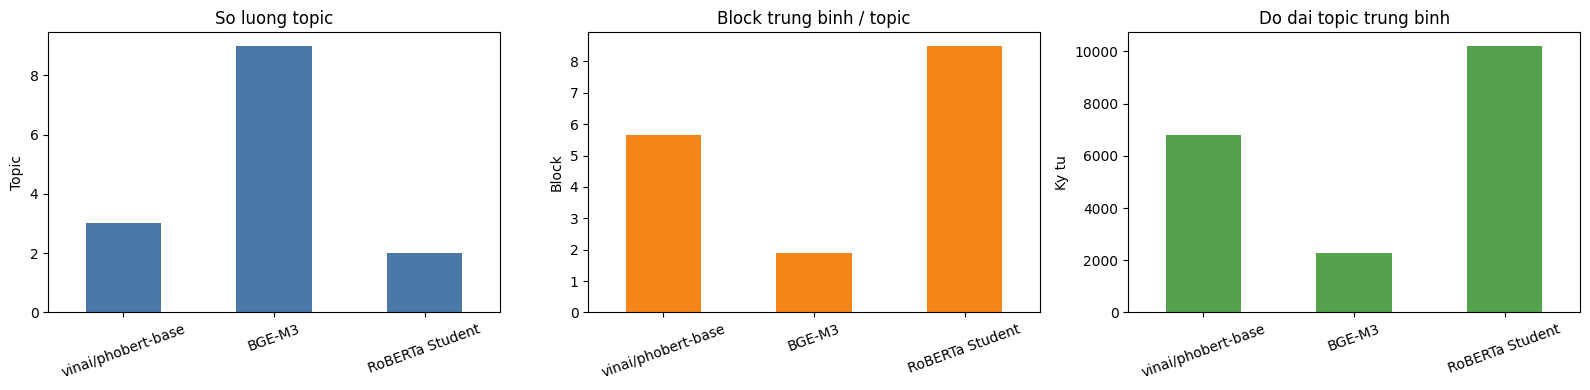

Thời gian chạy cell so sánh topic: 0.88 giây


In [193]:
import time
start = time.time()


def topic_duration(topic):
    return float(topic.get("end_time", 0)) - float(topic.get("start_time", 0))


topic_rows = []
for item in MODEL_OUTPUTS:
    topic_list = item["topics"]
    block_list = item["blocks"]
    topic_rows.append({
        "model": item["model"],
        "num_blocks": len(block_list),
        "num_topics": len(topic_list),
        "avg_blocks_per_topic": np.mean([len(t.get("block_ids", [])) for t in topic_list]) if topic_list else 0,
        "avg_topic_seconds": np.mean([topic_duration(t) for t in topic_list]) if topic_list else 0,
        "avg_topic_chars": np.mean([len(t.get("text", "")) for t in topic_list]) if topic_list else 0,
        "total_topic_chars": sum(len(t.get("text", "")) for t in topic_list),
    })

topic_compare_df = pd.DataFrame(topic_rows)
display(topic_compare_df)
topic_compare_df.to_csv("outputs/topic_compare_3_models.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
topic_compare_df.plot(x="model", y="num_topics", kind="bar", ax=axes[0], legend=False, color="#4C78A8")
axes[0].set_title("So luong topic")
axes[0].set_xlabel("")
axes[0].set_ylabel("Topic")

topic_compare_df.plot(x="model", y="avg_blocks_per_topic", kind="bar", ax=axes[1], legend=False, color="#F58518")
axes[1].set_title("Block trung binh / topic")
axes[1].set_xlabel("")
axes[1].set_ylabel("Block")

topic_compare_df.plot(x="model", y="avg_topic_chars", kind="bar", ax=axes[2], legend=False, color="#54A24B")
axes[2].set_title("Do dai topic trung binh")
axes[2].set_xlabel("")
axes[2].set_ylabel("Ky tu")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("outputs/topic_compare_3_models.png", dpi=160, bbox_inches="tight")
plt.show()

end = time.time()
print(f"Thời gian chạy cell so sánh topic: {end - start:.2f} giây")


## Bảng và biểu đồ so sánh tóm tắt


,model,num_topic_summaries,total_topic_summary_chars,avg_topic_summary_chars,final_summary_chars,final_summary_preview
0,vinai/phobert-base,3,1449,483.000000,1579,FINAL SUMMARY 1. Tóm tắt ngắn: Video này giới...
1,BGE-M3,9,4404,489.333333,2013,FINAL SUMMARY 1. Tóm tắt ngắn: AI không chỉ g...
2,RoBERTa Student,2,1291,645.500000,1234,FINAL SUMMARY 1. Tóm tắt ngắn: Video này giới...


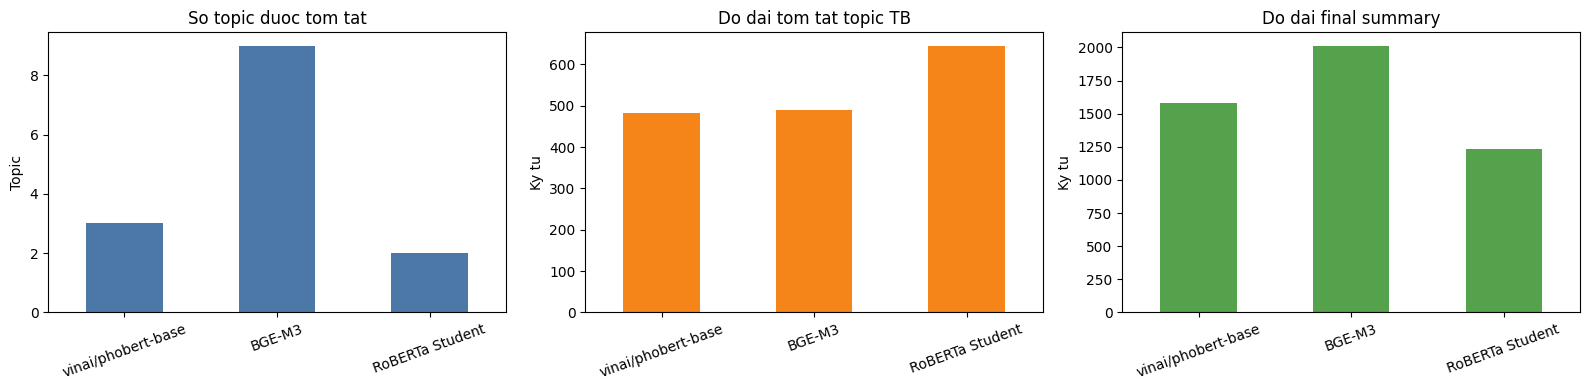

Thời gian chạy cell so sánh tóm tắt: 0.66 giây


In [194]:
import time
start = time.time()

summary_rows = []
for item in MODEL_OUTPUTS:
    topic_list = item["topics"]
    final_summary = item["final_summary"] or ""
    topic_summary_lengths = [len(t.get("summary_raw", "")) for t in topic_list]

    summary_rows.append({
        "model": item["model"],
        "num_topic_summaries": len(topic_summary_lengths),
        "total_topic_summary_chars": sum(topic_summary_lengths),
        "avg_topic_summary_chars": np.mean(topic_summary_lengths) if topic_summary_lengths else 0,
        "final_summary_chars": len(final_summary),
        "final_summary_preview": final_summary[:350].replace("\n", " "),
    })

summary_compare_df = pd.DataFrame(summary_rows)
display(summary_compare_df)
summary_compare_df.to_csv("outputs/summary_compare_3_models.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
summary_compare_df.plot(x="model", y="num_topic_summaries", kind="bar", ax=axes[0], legend=False, color="#4C78A8")
axes[0].set_title("So topic duoc tom tat")
axes[0].set_xlabel("")
axes[0].set_ylabel("Topic")

summary_compare_df.plot(x="model", y="avg_topic_summary_chars", kind="bar", ax=axes[1], legend=False, color="#F58518")
axes[1].set_title("Do dai tom tat topic TB")
axes[1].set_xlabel("")
axes[1].set_ylabel("Ky tu")

summary_compare_df.plot(x="model", y="final_summary_chars", kind="bar", ax=axes[2], legend=False, color="#54A24B")
axes[2].set_title("Do dai final summary")
axes[2].set_xlabel("")
axes[2].set_ylabel("Ky tu")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("outputs/summary_compare_3_models.png", dpi=160, bbox_inches="tight")
plt.show()

end = time.time()
print(f"Thời gian chạy cell so sánh tóm tắt: {end - start:.2f} giây")


## Bảng và biểu đồ so sánh QA


,model,answer_chars,retrieved_blocks,avg_score,top_score,block_ids,timestamps,answer_preview
0,vinai/phobert-base,1736,5,0.572873,0.584132,"4, 1, 15, 5, 7",04:00-05:00; 01:00-02:00; 15:00-16:00; 05:00-0...,CAU TRA LOI: Video này không đề cập đến việc...
1,BGE-M3,801,5,0.395087,0.424716,"16, 9, 1, 3, 10",16:00-17:00; 09:00-10:00; 01:00-02:00; 03:00-0...,CAU TRA LOI: Video này không đề cập đến việc...
2,RoBERTa Student,1496,5,0.737478,0.771397,"5, 10, 8, 16, 14",05:00-06:00; 10:00-11:00; 08:00-09:00; 16:00-1...,CAU TRA LOI: Video này không đề cập đến việc...


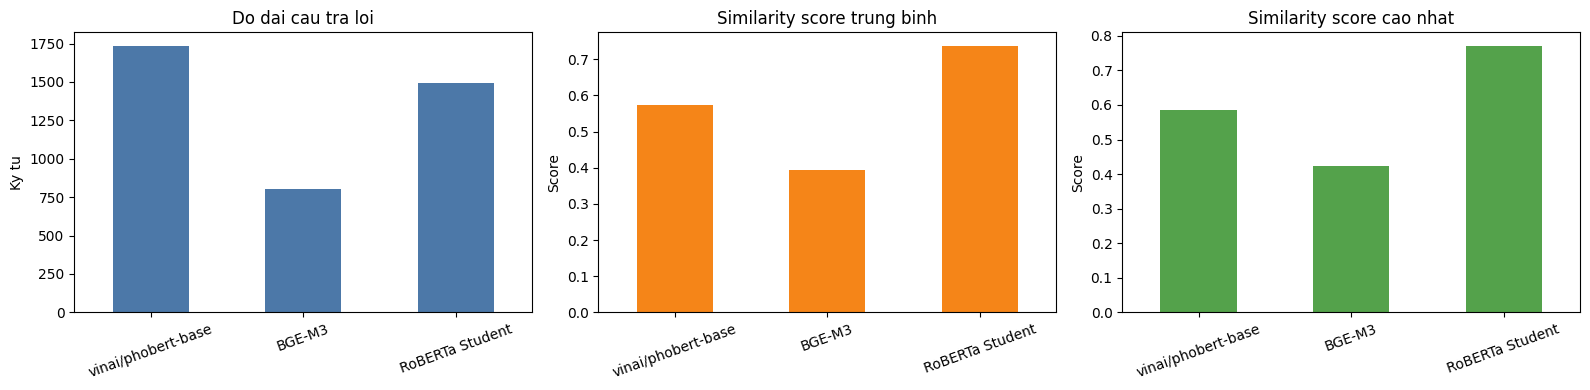

Thời gian chạy cell so sánh QA: 0.67 giây


In [195]:
import time
start = time.time()

qa_rows = []
for item in MODEL_OUTPUTS:
    qa_result = item["qa_result"]
    retrieved_blocks = qa_result.get("retrieved_blocks", [])
    scores = [b.get("score", 0) for b in retrieved_blocks]
    block_ids = [str(b.get("block_id")) for b in retrieved_blocks]
    timestamps = [f'{format_time(b.get("start_time", 0))}-{format_time(b.get("end_time", 0))}' for b in retrieved_blocks]
    answer = qa_result.get("answer", "")

    qa_rows.append({
        "model": item["model"],
        "answer_chars": len(answer),
        "retrieved_blocks": len(retrieved_blocks),
        "avg_score": np.mean(scores) if scores else 0,
        "top_score": max(scores) if scores else 0,
        "block_ids": ", ".join(block_ids),
        "timestamps": "; ".join(timestamps),
        "answer_preview": answer[:500].replace("\n", " "),
    })

qa_compare_df = pd.DataFrame(qa_rows)
display(qa_compare_df)
qa_compare_df.to_csv("outputs/qa_compare_3_models.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
qa_compare_df.plot(x="model", y="answer_chars", kind="bar", ax=axes[0], legend=False, color="#4C78A8")
axes[0].set_title("Do dai cau tra loi")
axes[0].set_xlabel("")
axes[0].set_ylabel("Ky tu")

qa_compare_df.plot(x="model", y="avg_score", kind="bar", ax=axes[1], legend=False, color="#F58518")
axes[1].set_title("Similarity score trung binh")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")

qa_compare_df.plot(x="model", y="top_score", kind="bar", ax=axes[2], legend=False, color="#54A24B")
axes[2].set_title("Similarity score cao nhat")
axes[2].set_xlabel("")
axes[2].set_ylabel("Score")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("outputs/qa_compare_3_models.png", dpi=160, bbox_inches="tight")
plt.show()

end = time.time()
print(f"Thời gian chạy cell so sánh QA: {end - start:.2f} giây")


## Bảng tổng hợp cuối


,model,num_blocks,num_topics,avg_blocks_per_topic,avg_topic_chars,avg_topic_summary_chars,final_summary_chars,answer_chars,avg_score,top_score,block_ids
0,vinai/phobert-base,17,3,5.666667,6814.666667,483.000000,1579,1736,0.572873,0.584132,"4, 1, 15, 5, 7"
1,BGE-M3,17,9,1.888889,2270.888889,489.333333,2013,801,0.395087,0.424716,"16, 9, 1, 3, 10"
2,RoBERTa Student,17,2,8.500000,10222.500000,645.500000,1234,1496,0.737478,0.771397,"5, 10, 8, 16, 14"


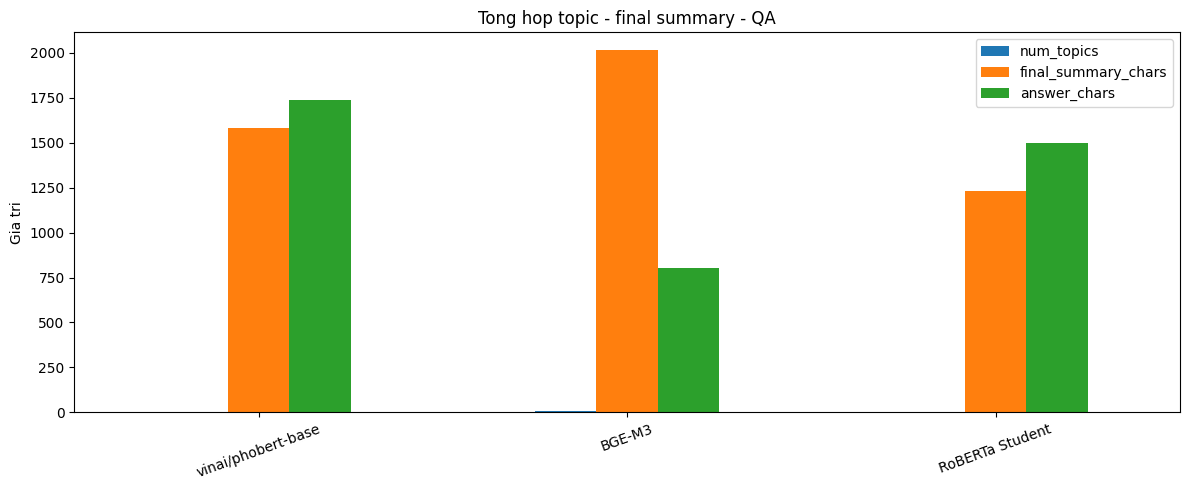

Saved comparison files:
outputs/topic_compare_3_models.csv
outputs/summary_compare_3_models.csv
outputs/qa_compare_3_models.csv
outputs/overview_compare_3_models.csv
outputs/topic_compare_3_models.png
outputs/summary_compare_3_models.png
outputs/qa_compare_3_models.png
outputs/overview_compare_3_models.png
Thời gian chạy cell bảng tổng hợp: 0.38 giây


In [196]:
import time
start = time.time()

overview_df = (
    topic_compare_df[["model", "num_blocks", "num_topics", "avg_blocks_per_topic", "avg_topic_chars"]]
    .merge(summary_compare_df[["model", "avg_topic_summary_chars", "final_summary_chars"]], on="model")
    .merge(qa_compare_df[["model", "answer_chars", "avg_score", "top_score", "block_ids"]], on="model")
)

display(overview_df)
overview_df.to_csv("outputs/overview_compare_3_models.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = overview_df.set_index("model")[["num_topics", "final_summary_chars", "answer_chars"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Tong hop topic - final summary - QA")
ax.set_xlabel("")
ax.set_ylabel("Gia tri")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("outputs/overview_compare_3_models.png", dpi=160, bbox_inches="tight")
plt.show()

print("Saved comparison files:")
print("outputs/topic_compare_3_models.csv")
print("outputs/summary_compare_3_models.csv")
print("outputs/qa_compare_3_models.csv")
print("outputs/overview_compare_3_models.csv")
print("outputs/topic_compare_3_models.png")
print("outputs/summary_compare_3_models.png")
print("outputs/qa_compare_3_models.png")
print("outputs/overview_compare_3_models.png")

end = time.time()
print(f"Thời gian chạy cell bảng tổng hợp: {end - start:.2f} giây")
